In [1]:
import random
import pandas as pd

def banka_simulasyonu(musteri_sayisi=100):
    ort_gelis_suresi = 5  
    ort_servis_suresi = 4 

    gelis_zamanlari = []
    servis_baslama_zamanlari = []
    bitis_zamanlari = []
    bekleme_sureleri = []
    kuyruk_uzunluklari = []

    su_anki_zaman = 0.0
    gise_bosalma_zamani = 0.0

    for i in range(musteri_sayisi):
        gelis_araligi = random.expovariate(1.0 / ort_gelis_suresi)
        su_anki_zaman += gelis_araligi
        gelis_zamanlari.append(su_anki_zaman)

        
        sistemdeki_kisi_sayisi = sum(1 for bitis in bitis_zamanlari if bitis > su_anki_zaman)
        kuyruk_uzunlugu = max(0, sistemdeki_kisi_sayisi - 1) 
        kuyruk_uzunluklari.append(kuyruk_uzunlugu)

        
        servis_baslama = max(su_anki_zaman, gise_bosalma_zamani)
        servis_baslama_zamanlari.append(servis_baslama)

        
        bekleme_suresi = servis_baslama - su_anki_zaman
        bekleme_sureleri.append(bekleme_suresi)

        
        servis_suresi = random.expovariate(1.0 / ort_servis_suresi)
        gise_bosalma_zamani = servis_baslama + servis_suresi
        bitis_zamanlari.append(gise_bosalma_zamani)

    
    sonuclar_df = pd.DataFrame({
        'Müşteri No': range(1, musteri_sayisi + 1),
        'Geliş Zamanı': gelis_zamanlari,
        'Servis Başlama': servis_baslama_zamanlari,
        'Bekleme Süresi': bekleme_sureleri,
        'Servis Bitiş': bitis_zamanlari,
        'Geliş Anındaki Kuyruk': kuyruk_uzunluklari
    })

    return sonuclar_df


if __name__ == "__main__":
    ornek_sonuc = banka_simulasyonu(100)
    print("Simülasyon Algoritması Başarıyla Çalıştı!\n")
    print("İlk 5 Müşterinin Simülasyon Çıktısı:")
    print(ornek_sonuc.head())

Simülasyon Algoritması Başarıyla Çalıştı!

İlk 5 Müşterinin Simülasyon Çıktısı:
   Müşteri No  Geliş Zamanı  Servis Başlama  Bekleme Süresi  Servis Bitiş  \
0           1      8.867947        8.867947        0.000000     21.975344   
1           2     11.481608       21.975344       10.493737     21.976544   
2           3     16.691317       21.976544        5.285227     24.380287   
3           4     20.153242       24.380287        4.227045     26.928075   
4           5     21.724442       26.928075        5.203633     28.149229   

   Geliş Anındaki Kuyruk  
0                      0  
1                      0  
2                      1  
3                      2  
4                      3  


In [2]:
import pandas as pd

def deneyleri_yap(deney_sayisi=10, musteri_sayisi=100):
    deney_sonuclari = []

    for deney_no in range(1, deney_sayisi + 1):
        simulasyon_verisi = banka_simulasyonu(musteri_sayisi)
        
        ort_bekleme = simulasyon_verisi['Bekleme Süresi'].mean()
        
        deney_sonuclari.append({
            'Deney No': deney_no,
            'Ortalama Bekleme Süresi (Dakika)': round(ort_bekleme, 2)
        })
    deneyler_df = pd.DataFrame(deney_sonuclari)
    
    return deneyler_df

if __name__ == "__main__":
    tablo_sonuclari = deneyleri_yap(10, 100)
    print("10 Bağımsız Simülasyon Çalıştırması Sonuç Tablosu:\n")
    print(tablo_sonuclari.to_string(index=False))

10 Bağımsız Simülasyon Çalıştırması Sonuç Tablosu:

 Deney No  Ortalama Bekleme Süresi (Dakika)
        1                             25.40
        2                             10.49
        3                              9.26
        4                             39.69
        5                             11.23
        6                             22.77
        7                             15.35
        8                             15.62
        9                              4.91
       10                             11.13


Genel Ortalama Bekleme Süresi: 10.84 dakika
Bekleme Süresi Ortalamalarının Standart Sapması: 11.58 dakika



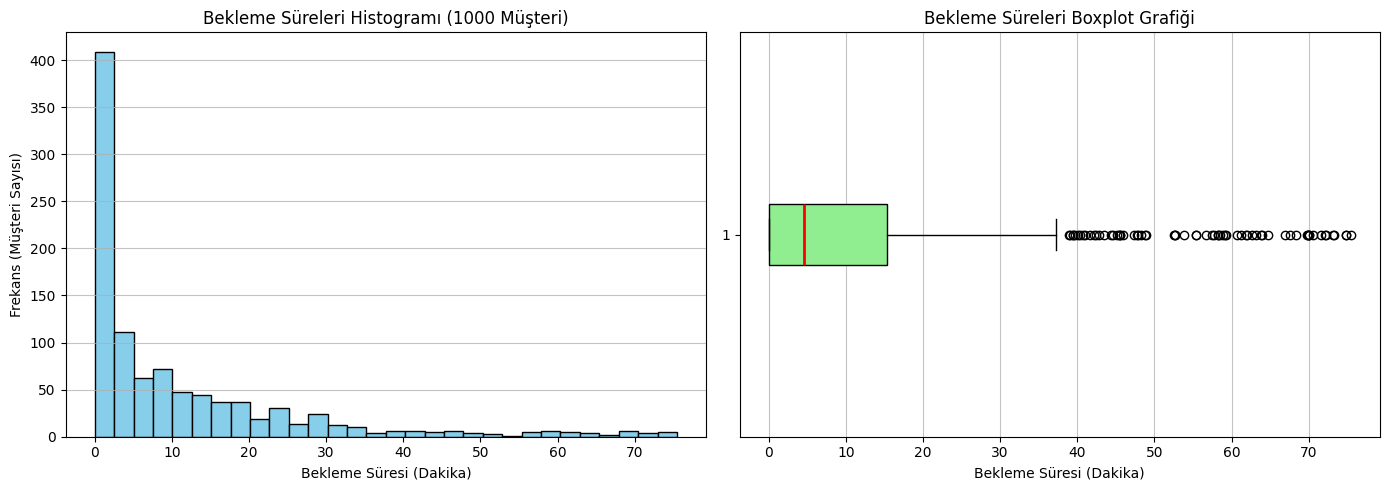

In [3]:
import matplotlib.pyplot as plt
import numpy as np

tum_bekleme_sureleri = []
deney_ortalamalari = []

for _ in range(10):
    simulasyon_verisi = banka_simulasyonu(100)
    tum_bekleme_sureleri.extend(simulasyon_verisi['Bekleme Süresi'].tolist())
    deney_ortalamalari.append(simulasyon_verisi['Bekleme Süresi'].mean())

genel_ortalama = np.mean(deney_ortalamalari)
standart_sapma = np.std(deney_ortalamalari, ddof=1)

print(f"Genel Ortalama Bekleme Süresi: {genel_ortalama:.2f} dakika")
print(f"Bekleme Süresi Ortalamalarının Standart Sapması: {standart_sapma:.2f} dakika\n")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(tum_bekleme_sureleri, bins=30, color='skyblue', edgecolor='black')
plt.title('Bekleme Süreleri Histogramı (1000 Müşteri)')
plt.xlabel('Bekleme Süresi (Dakika)')
plt.ylabel('Frekans (Müşteri Sayısı)')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
plt.boxplot(tum_bekleme_sureleri, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Bekleme Süreleri Boxplot Grafiği')
plt.xlabel('Bekleme Süresi (Dakika)')
plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()